# QED, SA, and Docking Score Validity Analysis

This section loads the DeepBioisostere, random, and frequency-generated results, computes the QED, SA, and docking score validities, and summarizes the joint performance. The joint validity (`is_valid`) is defined as the intersection of all three criteria.

## Performance Analysis

- **QED valid**: Fraction of molecules with improved QED.
- **SA valid**: Fraction of molecules with improved synthetic accessibility (SA).
- **Score valid**: Fraction of molecules with docking score difference (generated - input) within ±1.36.
- **Joint valid**: Fraction of molecules satisfying all three criteria simultaneously.

The table above allows direct comparison of each method. The joint validity is typically lower than individual metrics, reflecting the strictness of requiring all criteria to be met. If one metric is much lower than the others, it is likely the main bottleneck for joint success.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import pandas as pd

In [3]:
SBDD_DIR = Path("/home/share/DATA/wonho_SBDD_models_eval")
# "/home/share/DATA/wonho_SBDD_models_eval/pocket2mol_eval/result.csv"
PROJECT_DIR = Path("/home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere")
EXP_DIR = PROJECT_DIR / "exps/fig5_new_case_study"
DATE = "20250826_new_data_main_model"
ABLATION_DATE = "20250826_new_data_ablation_model"
OUTPUT_DIR = EXP_DIR / DATE / "summary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AFF_CRITERIA = 1.36
MODELS = ["pocket2mol", "targetdiff", "decompdiff", "DeepICL"]
TARGETS = [36, 68, 84]
# TARGETS = [67]


# ABLATION STUDY

In [4]:
for model_name in MODELS:
    orig_df = pd.read_csv(SBDD_DIR / f"{model_name}_eval/result.csv")
    for target_idx in TARGETS:
        # File paths
        # random_path = (
        #     EXP_DIR
        #     / DATE
        #     / f"docking_gpu_results/summary_{model_name}_{target_idx}_random.csv"
        # )
        # frequency_path = (
        #     EXP_DIR
        #     / DATE
        #     / f"docking_gpu_results/summary_{model_name}_{target_idx}_frequency.csv"
        # )
        # rank_filtered_mmpa_path = (
        #     EXP_DIR
        #     / DATE
        #     / f"docking_gpu_results/summary_{model_name}_{target_idx}_rank_filtered_mmpa_qed_sa_10.csv"
        # )
        deepbio_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_0.10_-1.0.csv"
        )
        ablation_path = (
            EXP_DIR
            / ABLATION_DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_0.10_-1.0.csv"
        )
        print(deepbio_path, ablation_path)
        if any(
            # not path.exists() for path in [random_path, frequency_path, deepbio_path]
            not path.exists() for path in [deepbio_path, ablation_path]
        ):
            print(
                f"Skipping {model_name} for target {target_idx} due to missing files."
            )
            continue

        # data_type = random_path.stem.split("_", 3)[-1]
        data_type = deepbio_path.stem.split("_", 3)[-1]

        # Load data
        # random_df = pd.read_csv(random_path)
        # frequency_df = pd.read_csv(frequency_path)
        # rank_filtered_mmpa_df = pd.read_csv(rank_filtered_mmpa_path)
        deepbio_df = pd.read_csv(deepbio_path)
        ablation_df = pd.read_csv(ablation_path)

        # Compute validity columns
        # for df in [random_df, frequency_df, rank_filtered_mmpa_df, deepbio_df]:
        for df in [deepbio_df, ablation_df]:
            df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
            df["QED_valid"] = df["QED_DIFF"] > 0
            df["SA_valid"] = df["SA_DIFF"] < 0
            df["SCORE_valid"] = df["SCORE_DIFF"].abs() < AFF_CRITERIA
            df["is_valid"] = df["QED_valid"] & df["SA_valid"] & df["SCORE_valid"]

        _count_df = orig_df.copy()
        _count_df = _count_df[_count_df["test_idx"] == target_idx]
        _count_df = _count_df["SMILES"][~_count_df["SMILES"].isna()]
        unique_count = _count_df.nunique()

        # Summarize
        summary = pd.DataFrame(
            {
                "QED_valid": [
                    # random_df["QED_valid"].mean(),
                    # frequency_df["QED_valid"].mean(),
                    # rank_filtered_mmpa_df["QED_valid"].mean(),
                    ablation_df["QED_valid"].mean(),
                    deepbio_df["QED_valid"].mean(),
                ],
                "SA_valid": [
                    # random_df["SA_valid"].mean(),
                    # frequency_df["SA_valid"].mean(),
                    # rank_filtered_mmpa_df["SA_valid"].mean(),
                    ablation_df["SA_valid"].mean(),
                    deepbio_df["SA_valid"].mean(),
                ],
                "SCORE_valid": [
                    # random_df["SCORE_valid"].mean(),
                    # frequency_df["SCORE_valid"].mean(),
                    # rank_filtered_mmpa_df["SCORE_valid"].mean(),
                    ablation_df["SCORE_valid"].mean(),
                    deepbio_df["SCORE_valid"].mean(),
                ],
                "is_valid (joint)": [
                    # random_df["is_valid"].mean(),
                    # frequency_df["is_valid"].mean(),
                    # rank_filtered_mmpa_df["is_valid"].mean(),
                    ablation_df["is_valid"].mean(),
                    deepbio_df["is_valid"].mean(),
                ],
                "Generated Ratio": [
                    # len(random_df) / unique_count,
                    # len(frequency_df) / unique_count,
                    # len(rank_filtered_mmpa_df) / unique_count,
                    len(ablation_df) / unique_count,
                    len(deepbio_df) / unique_count,
                ],
            },
            # index=["Random", "Frequent", "Rank-filtered MMPA", "DeepBioisostere"],
            index=["Ablation", "DeepBioisostere"],
        )

        print(f"Summary for {model_name} on target {target_idx}:")
        print(summary)

        summary.to_markdown(
            OUTPUT_DIR / f"ablation_validity_{model_name}_{target_idx}.md", floatfmt=".2f"
        )
        summary.to_csv(
            OUTPUT_DIR / f"ablation_validity_{model_name}_{target_idx}.csv",
        )

/home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere/exps/fig5_new_case_study/20250826_new_data_main_model/docking_gpu_results/summary_pocket2mol_36_0.10_-1.0.csv /home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere/exps/fig5_new_case_study/20250826_new_data_ablation_model/docking_gpu_results/summary_pocket2mol_36_0.10_-1.0.csv
Summary for pocket2mol on target 36:
                 QED_valid  SA_valid  SCORE_valid  is_valid (joint)  \
Ablation          0.729333  0.628496     0.676669          0.341090   
DeepBioisostere   0.740703  0.610135     0.679812          0.358807   

                 Generated Ratio  
Ablation               51.031250  
DeepBioisostere        50.979167  
/home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere/exps/fig5_new_case_study/20250826_new_data_main_model/docking_gpu_results/summary_pocket2mol_68_0.10_-1.0.csv /home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere/exps/fig5_new_case_study/20250826_new_data_ablatio

---

In [5]:
for model_name in MODELS:
    orig_df = pd.read_csv(SBDD_DIR / f"{model_name}_eval/result.csv")
    for target_idx in TARGETS:
        # File paths
        random_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_random.csv"
        )
        frequency_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_frequency.csv"
        )
        rank_filtered_mmpa_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_rank_filtered_mmpa_qed_sa_10.csv"
        )
        deepbio_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_0.10_-1.0.csv"
        )
        if any(
            not path.exists() for path in [random_path, frequency_path, deepbio_path]
        ):
            print(
                f"Skipping {model_name} for target {target_idx} due to missing files."
            )
            continue

        data_type = random_path.stem.split("_", 3)[-1]

        # Load data
        random_df = pd.read_csv(random_path)
        frequency_df = pd.read_csv(frequency_path)
        rank_filtered_mmpa_df = pd.read_csv(rank_filtered_mmpa_path)
        deepbio_df = pd.read_csv(deepbio_path)

        # Compute validity columns
        for df in [random_df, frequency_df, rank_filtered_mmpa_df, deepbio_df]:
            df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
            df["QED_valid"] = df["QED_DIFF"] > 0
            df["SA_valid"] = df["SA_DIFF"] < 0
            df["SCORE_valid"] = df["SCORE_DIFF"].abs() < AFF_CRITERIA
            df["is_valid"] = df["QED_valid"] & df["SA_valid"] & df["SCORE_valid"]

        _count_df = orig_df.copy()
        _count_df = _count_df[_count_df["test_idx"] == target_idx]
        _count_df = _count_df["SMILES"][~_count_df["SMILES"].isna()]
        unique_count = _count_df.nunique()

        # Summarize
        summary = pd.DataFrame(
            {
                "QED_valid": [
                    random_df["QED_valid"].mean(),
                    frequency_df["QED_valid"].mean(),
                    rank_filtered_mmpa_df["QED_valid"].mean(),
                    deepbio_df["QED_valid"].mean(),
                ],
                "SA_valid": [
                    random_df["SA_valid"].mean(),
                    frequency_df["SA_valid"].mean(),
                    rank_filtered_mmpa_df["SA_valid"].mean(),
                    deepbio_df["SA_valid"].mean(),
                ],
                "SCORE_valid": [
                    random_df["SCORE_valid"].mean(),
                    frequency_df["SCORE_valid"].mean(),
                    rank_filtered_mmpa_df["SCORE_valid"].mean(),
                    deepbio_df["SCORE_valid"].mean(),
                ],
                "is_valid (joint)": [
                    random_df["is_valid"].mean(),
                    frequency_df["is_valid"].mean(),
                    rank_filtered_mmpa_df["is_valid"].mean(),
                    deepbio_df["is_valid"].mean(),
                ],
                "Generated Ratio": [
                    len(random_df) / unique_count,
                    len(frequency_df) / unique_count,
                    len(rank_filtered_mmpa_df) / unique_count,
                    len(deepbio_df) / unique_count,
                ],
            },
            index=["Random", "Frequent", "Rank-filtered MMPA", "DeepBioisostere"],
        )

        print(f"Summary for {model_name} on target {target_idx}:")
        print(summary)

        summary.to_markdown(
            OUTPUT_DIR / f"validity_{model_name}_{target_idx}.md", floatfmt=".2f"
        )
        summary.to_csv(
            OUTPUT_DIR / f"validity_{model_name}_{target_idx}.csv",
        )

Summary for pocket2mol on target 36:
                    QED_valid  SA_valid  SCORE_valid  is_valid (joint)  \
Random               0.774057  0.449776     0.663064          0.222252   
Frequent             0.761465  0.513179     0.750395          0.276226   
Rank-filtered MMPA   0.768087  0.436444     0.749493          0.234956   
DeepBioisostere      0.740703  0.610135     0.679812          0.358807   

                    Generated Ratio  
Random                    39.510417  
Frequent                  39.520833  
Rank-filtered MMPA        30.812500  
DeepBioisostere           50.979167  
Summary for pocket2mol on target 68:
                    QED_valid  SA_valid  SCORE_valid  is_valid (joint)  \
Random               0.622318  0.385653     0.914572          0.240139   
Frequent             0.672724  0.510412     0.971213          0.355451   
Rank-filtered MMPA   0.644597  0.416452     0.979650          0.300659   
DeepBioisostere      0.747485  0.740603     0.938768          0.55832

In [6]:
for model_name in MODELS:
    for target_idx in TARGETS:
        # File paths
        random_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_random.csv"
        )
        frequency_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_frequency.csv"
        )
        deepbio_path = (
            EXP_DIR
            / DATE
            / f"docking_gpu_results/summary_{model_name}_{target_idx}_0.10_-1.0.csv"
        )
        if any(
            not path.exists() for path in [random_path, frequency_path, deepbio_path]
        ):
            print(
                f"Skipping {model_name} for target {target_idx} due to missing files."
            )
            continue

        # Load data
        random_df = pd.read_csv(random_path)
        freq_df = pd.read_csv(frequency_path)
        deepbio_df = pd.read_csv(deepbio_path)

        # Compute validity columns
        for df in [random_df, freq_df, deepbio_df]:
            df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
            df["QED_valid"] = df["QED_DIFF"] > 0
            df["SA_valid"] = df["SA_DIFF"] < 0
            df["SCORE_valid"] = df["SCORE_DIFF"].abs() < 1.36
            df["is_valid"] = df["QED_valid"] & df["SA_valid"] & df["SCORE_valid"]
            df["QED_original"] = df["QED"] - df["QED_DIFF"]
            df["SA_original"] = df["SA"] - df["SA_DIFF"]

        # NOTE: original values are different due to number of generation difference
        # NOTE: DeepBioisostere generation why more than others?

        # Summarize
        summary = pd.DataFrame(
            {
                "QED(mean)": [
                    deepbio_df["QED_original"].mean(),
                    random_df["QED"].mean(),
                    freq_df["QED"].mean(),
                    deepbio_df["QED"].mean(),
                ],
                "QED(median)": [
                    deepbio_df["QED_original"].median(),
                    random_df["QED"].median(),
                    freq_df["QED"].median(),
                    deepbio_df["QED"].median(),
                ],
                "QED(std)": [
                    deepbio_df["QED_original"].std(),
                    random_df["QED"].std(),
                    freq_df["QED"].std(),
                    deepbio_df["QED"].std(),
                ],
                "SA(mean)": [
                    deepbio_df["SA_original"].mean(),
                    random_df["SA"].mean(),
                    freq_df["SA"].mean(),
                    deepbio_df["SA"].mean(),
                ],
                "SA(median)": [
                    deepbio_df["SA_original"].median(),
                    random_df["SA"].median(),
                    freq_df["SA"].median(),
                    deepbio_df["SA"].median(),
                ],
                "SA(std)": [
                    deepbio_df["SA_original"].std(),
                    random_df["SA"].std(),
                    freq_df["SA"].std(),
                    deepbio_df["SA"].std(),
                ],
                "SCORE(mean)": [
                    deepbio_df["INPUT-MOL-DOCKED-SCORE"].mean(),
                    random_df["GEN-MOL-DOCKED-SCORE"].mean(),
                    freq_df["GEN-MOL-DOCKED-SCORE"].mean(),
                    deepbio_df["GEN-MOL-DOCKED-SCORE"].mean(),
                ],
                "SCORE(median)": [
                    deepbio_df["INPUT-MOL-DOCKED-SCORE"].median(),
                    random_df["GEN-MOL-DOCKED-SCORE"].median(),
                    freq_df["GEN-MOL-DOCKED-SCORE"].median(),
                    deepbio_df["GEN-MOL-DOCKED-SCORE"].median(),
                ],
                "SCORE(std)": [
                    deepbio_df["INPUT-MOL-DOCKED-SCORE"].std(),
                    random_df["GEN-MOL-DOCKED-SCORE"].std(),
                    freq_df["GEN-MOL-DOCKED-SCORE"].std(),
                    deepbio_df["GEN-MOL-DOCKED-SCORE"].std(),
                ],
            },
            index=["Original", "Random", "Frequent", "DeepBioisostere"],
        )

        print(f"Summary for {model_name} on target {target_idx}:")
        print(summary)
        summary.to_markdown(
            OUTPUT_DIR / f"mean_median_std_{model_name}_{target_idx}.md", floatfmt=".2f"
        )
        summary.to_csv(
            OUTPUT_DIR / f"mean_median_std_{model_name}_{target_idx}.csv",
        )

Summary for pocket2mol on target 36:
                 QED(mean)  QED(median)  QED(std)  SA(mean)  SA(median)  \
Original          0.509130     0.509617  0.129892  3.258459    3.610000   
Random            0.610161     0.620433  0.158791  3.321658    3.393102   
Frequent          0.590403     0.603619  0.141250  3.200156    3.284825   
DeepBioisostere   0.596788     0.615494  0.135736  3.133881    3.267851   

                  SA(std)  SCORE(mean)  SCORE(median)  SCORE(std)  
Original         0.975680    -6.896567           -6.9    0.498295  
Random           0.994691    -5.872423           -6.0    1.033030  
Frequent         1.024025    -6.100474           -6.2    0.868152  
DeepBioisostere  0.990714    -5.949203           -6.0    0.767423  
Summary for pocket2mol on target 68:
                 QED(mean)  QED(median)  QED(std)  SA(mean)  SA(median)  \
Original          0.564931     0.603270  0.172441  3.527909    3.700000   
Random            0.615820     0.639738  0.178540  3.541107 

---

# CASE STUDY VISUALIZATION

In [7]:
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS, rdDepictor

In [8]:
def filter_df(df, QED_DIFF=0.09):
    df["SCORE_DIFF"] = df["GEN-MOL-DOCKED-SCORE"] - df["INPUT-MOL-DOCKED-SCORE"]
    df = df[df["QED"] > 0.4]
    df = df[df["QED_DIFF"] > 0]
    df = df[df["QED_DIFF"] <= 0.1]
    df = df[df["SA_DIFF"] < 0]
    df = df[df["SA_DIFF"] >= -1.0]
    df = df[df["SCORE_DIFF"].abs() < 1.36]
    df = df[df["QED_DIFF"] > QED_DIFF].sort_values(by="SA_DIFF", ascending=True)
    return df

In [9]:
def remove_dummy_atoms(mol):
    dummy = Chem.MolFromSmiles("*")
    _mol = AllChem.ReplaceSubstructs(mol, dummy, Chem.MolFromSmiles("[H]"), True)[0]
    mol = Chem.RemoveHs(_mol)
    return mol


def _draw_molecule_with_options(
    mol, size, highlight_atoms, highlight_bonds, highlight_color, scale
):
    """Enhanced molecule drawing with thicker bonds and larger atom labels"""
    from rdkit.Chem.Draw import rdMolDraw2D
    import io

    # Create a drawer with enhanced options
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])

    # Get drawing options and enhance them
    opts = drawer.drawOptions()

    # Increase bond thickness (default is usually around 2)
    opts.bondLineWidth = 3 * scale  # Thicker bonds

    # Increase atom label font size (default is usually around 0.8)
    opts.atomLabelFontSize = int(28 * scale)  # Larger atom labels

    # Optional: other enhancements
    opts.highlightBondWidthMultiplier = 3  # Make highlighted bonds even thicker
    opts.multipleBondOffset = 0.05 * scale  # Adjust spacing for double/triple bonds

    # Set highlight colors if provided
    if highlight_atoms and highlight_color:
        atom_colors = {atom_idx: highlight_color for atom_idx in highlight_atoms}
        bond_colors = {bond_idx: highlight_color for bond_idx in highlight_bonds}

        drawer.DrawMolecule(
            mol,
            highlightAtoms=highlight_atoms,
            highlightBonds=highlight_bonds,
            highlightAtomColors=atom_colors,
            highlightBondColors=bond_colors,
        )
    else:
        drawer.DrawMolecule(mol)

    drawer.FinishDrawing()

    # Convert to PIL Image
    txt = drawer.GetDrawingText()
    img = Image.open(io.BytesIO(txt))

    return img


def draw_mols(
    original_smi: str,
    generated_smi: str,
    original_sa: float,
    original_qed: float,
    original_docking: float,
    generated_sa: float,
    generated_qed: float,
    generated_docking: float,
    leaving_frag_smi: str = None,
    inserting_frag_smi: str = None,
    scale: int = 1,
):
    mol_img_size = (350 * scale, 350 * scale)

    original_mol = Chem.MolFromSmiles(original_smi)
    generated_mol = Chem.MolFromSmiles(generated_smi)
    mols = [Chem.MolFromSmiles(original_smi), Chem.MolFromSmiles(generated_smi)]

    if not original_mol or not generated_mol:
        print("오류: 유효하지 않은 SMILES 문자열이 있습니다.")
        return None

    # MCS 찾기 (stereochemistry 제외)
    mcs_result = rdFMCS.FindMCS(
        mols,
        ringMatchesRingOnly=True,
        completeRingsOnly=True,
        timeout=5,
        matchChiralTag=False,  # stereochemistry 제외
    )
    if mcs_result.numAtoms < 1:
        print("경고: MCS를 찾지 못했습니다.")
        mcs_patt = None
    else:
        mcs_patt = Chem.MolFromSmarts(mcs_result.smartsString)

    if mcs_patt:
        rdDepictor.Compute2DCoords(original_mol)
        rdDepictor.Compute2DCoords(mcs_patt)
        rdDepictor.Compute2DCoords(generated_mol)
        rdDepictor.GenerateDepictionMatching2DStructure(original_mol, mcs_patt)
        rdDepictor.GenerateDepictionMatching2DStructure(generated_mol, mcs_patt)

    highlight_colors = []
    highlight_atom_lists = []
    highlight_bond_lists = []

    # 3. Leaving/Inserting Fragment 처리
    frags_to_process = [
        (original_mol, leaving_frag_smi, (0.7, 0.7, 1)),  # Leaving frag: Blueish
        (generated_mol, inserting_frag_smi, (1, 0.7, 0.7)),  # Inserting frag: Reddish
    ]

    for mol, frag_smi, color in frags_to_process:
        if not frag_smi or not mcs_patt:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        frag_mol = Chem.MolFromSmiles(frag_smi)
        # Dummy atom '*'를 제거하여 순수한 fragment 패턴 생성
        dummy = Chem.MolFromSmiles("*")
        frag_mol = AllChem.ReplaceSubstructs(
            frag_mol, dummy, Chem.MolFromSmiles("[H]"), True
        )[0]
        frag_mol = Chem.RemoveHs(frag_mol)

        # stereochemistry를 제거한 fragment pattern 생성
        # frag_smarts = Chem.MolToSmarts(frag_mol)
        # remove chirality specifications from SMARTS
        # frag_smarts = frag_smarts.replace('@', '').replace('@@', '')
        # frag_patt = Chem.MolFromSmarts(frag_smarts)
        frag_patt = frag_mol

        # Fragment가 매치되는 모든 위치 찾기 (stereochemistry 제외)
        params = Chem.SubstructMatchParameters()
        params.useEnhancedStereo = True
        all_matches = mol.GetSubstructMatches(frag_patt, params)

        if not all_matches:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        # MCS와 겹치지 않는 최적의 매치 찾기
        mcs_atoms_in_mol = set(mol.GetSubstructMatch(mcs_patt, useChirality=False))

        best_match = None
        min_overlap = float("inf")

        for match in reversed(all_matches):
            overlap = len(set(match).intersection(mcs_atoms_in_mol))
            if overlap < min_overlap:
                min_overlap = overlap
                best_match = match
                if min_overlap == 0:  # 겹치는 부분이 없으면 바로 선택
                    break

        hit_ats = list(best_match)
        highlight_atom_lists.append(hit_ats)

        # 하이라이트할 결합 찾기
        hit_bonds = []
        for bond in frag_patt.GetBonds():
            aid1 = hit_ats[bond.GetBeginAtomIdx()]
            aid2 = hit_ats[bond.GetEndAtomIdx()]
            mbond = mol.GetBondBetweenAtoms(aid1, aid2)
            if mbond:
                hit_bonds.append(mbond.GetIdx())
        highlight_bond_lists.append(hit_bonds)
        highlight_colors.append(color)

    # 4. 각 분자를 하이라이트하여 이미지로 렌더링 (향상된 drawing options 사용)
    original_img = _draw_molecule_with_options(
        original_mol,
        mol_img_size,
        highlight_atom_lists[0],
        highlight_bond_lists[0],
        highlight_colors[0],
        scale,
    )
    generated_img = _draw_molecule_with_options(
        generated_mol,
        mol_img_size,
        highlight_atom_lists[1],
        highlight_bond_lists[1],
        highlight_colors[1],
        scale,
    )

    # 2. 텍스트와 분자 이미지를 모두 담을 큰 캔버스 생성
    padding = 20 * scale
    spacing = 40 * scale
    text_area_height = 100 * scale

    total_width = mol_img_size[0] * 2 + spacing + padding * 2
    total_height = mol_img_size[1] + text_area_height + padding

    canvas = Image.new("RGB", (total_width, total_height), "white")

    # 3. 캔버스에 분자 이미지들 붙여넣기
    canvas.paste(original_img, (padding, padding))
    canvas.paste(generated_img, (padding + mol_img_size[0] + spacing, padding))

    # 4. 캔버스에 텍스트 그리기
    draw = ImageDraw.Draw(canvas)
    # font = ImageFont.truetype("LiberationSans-Regular.ttf", 24 * scale)
    font = ImageFont.truetype("DejaVuSans.ttf", 24 * scale)

    # 표시할 텍스트 준비
    original_text = f"Original\nQED: {original_qed:.2f}\nSA: {original_sa:.2f}\nDocking: {original_docking:.2f}"
    generated_text = f"Generated\nQED: {generated_qed:.2f}\nSA: {generated_sa:.2f}\nDocking: {generated_docking:.2f}"

    # 각 텍스트 블록의 위치 계산 (이미지 아래 중앙)
    original_text_pos_x = padding + mol_img_size[0] / 2
    generated_text_pos_x = padding + mol_img_size[0] + spacing + mol_img_size[0] / 2
    text_pos_y = padding + mol_img_size[1] + 10

    # 텍스트 그리기 (anchor='ms'는 텍스트의 '중간 상단'을 기준점으로 하여 중앙 정렬)
    draw.text(
        (original_text_pos_x, text_pos_y),
        original_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )
    draw.text(
        (generated_text_pos_x, text_pos_y),
        generated_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )

    # 5. 완성된 이미지 객체 반환
    return canvas

---

# MODEL: DeepICL, TARGET: 68 (visualization)

In [21]:
from rdkit.Chem.rdchem import ChiralType
from rdkit.Chem import AllChem
from rdkit.Chem import rdFMCS


def remove_dummy_atoms(mol):
    dummy = Chem.MolFromSmiles("*")
    _mol = AllChem.ReplaceSubstructs(mol, dummy, Chem.MolFromSmiles("[H]"), True)[0]
    mol = Chem.RemoveHs(_mol)
    return mol


def draw_mols(
    original_smi: str,
    generated_smi: str,
    original_sa: float,
    original_qed: float,
    original_docking: float,
    generated_sa: float,
    generated_qed: float,
    generated_docking: float,
    leaving_frag_smi: str = None,
    inserting_frag_smi: str = None,
    scale: int = 1,
):
    """
    Pillow를 사용하여 두 분자를 나란히 그리고, 각 분자 아래에 속성 값을 표시합니다.
    Jupyter Notebook에서 바로 표시할 수 있도록 PIL.Image 객체를 반환합니다.

    Args:
        (이전 함수와 동일)

    Returns:
        PIL.Image.Image: 최종적으로 생성된 이미지 객체.
    """
    # 1. RDKit으로 각 분자를 개별 이미지로 렌더링
    mol_img_size = (350 * scale, 350 * scale)

    original_mol = Chem.MolFromSmiles(original_smi)
    generated_mol = Chem.MolFromSmiles(generated_smi)
    mols = [Chem.MolFromSmiles(original_smi), Chem.MolFromSmiles(generated_smi)]

    if not original_mol or not generated_mol:
        print("오류: 유효하지 않은 SMILES 문자열이 있습니다.")
        return None

    mcs_result = rdFMCS.FindMCS(
        mols, ringMatchesRingOnly=True, completeRingsOnly=True, timeout=5
    )
    if mcs_result.numAtoms < 1:
        print("경고: MCS를 찾지 못했습니다.")
        mcs_patt = None
    else:
        mcs_patt = Chem.MolFromSmarts(mcs_result.smartsString)

    highlight_colors = []
    highlight_atom_lists = []
    highlight_bond_lists = []

    # 3. Leaving/Inserting Fragment 처리
    frags_to_process = [
        (original_mol, leaving_frag_smi, (0.7, 0.7, 1)),  # Leaving frag: Blueish
        (generated_mol, inserting_frag_smi, (1, 0.7, 0.7)),  # Inserting frag: Reddish
    ]

    for mol, frag_smi, color in frags_to_process:
        if not frag_smi or not mcs_patt:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        frag_mol = Chem.MolFromSmiles(frag_smi)
        # Dummy atom '*'를 제거하여 순수한 fragment 패턴 생성
        dummy = Chem.MolFromSmiles("*")
        frag_mol = AllChem.ReplaceSubstructs(
            frag_mol, dummy, Chem.MolFromSmiles("[H]"), True
        )[0]
        frag_mol = Chem.RemoveHs(frag_mol)
        frag_patt = Chem.MolFromSmarts(Chem.MolToSmarts(frag_mol))

        # Fragment가 매치되는 모든 위치 찾기
        all_matches = mol.GetSubstructMatches(frag_patt)

        if not all_matches:
            highlight_atom_lists.append([])
            highlight_bond_lists.append([])
            highlight_colors.append(color)
            continue

        # MCS와 겹치지 않는 최적의 매치 찾기
        mcs_atoms_in_mol = set(mol.GetSubstructMatch(mcs_patt))

        best_match = None
        min_overlap = float("inf")

        for match in all_matches:
            overlap = len(set(match).intersection(mcs_atoms_in_mol))
            if overlap < min_overlap:
                min_overlap = overlap
                best_match = match
                if min_overlap == 0:  # 겹치는 부분이 없으면 바로 선택
                    break

        hit_ats = list(best_match)
        highlight_atom_lists.append(hit_ats)

        # 하이라이트할 결합 찾기
        hit_bonds = []
        for bond in frag_patt.GetBonds():
            aid1 = hit_ats[bond.GetBeginAtomIdx()]
            aid2 = hit_ats[bond.GetEndAtomIdx()]
            mbond = mol.GetBondBetweenAtoms(aid1, aid2)
            if mbond:
                hit_bonds.append(mbond.GetIdx())
        highlight_bond_lists.append(hit_bonds)
        highlight_colors.append(color)

    # 4. 각 분자를 하이라이트하여 이미지로 렌더링
    mol_img_size = (350 * scale, 350 * scale)
    original_img = Draw.MolToImage(
        original_mol,
        size=mol_img_size,
        highlightAtoms=highlight_atom_lists[0],
        highlightBonds=highlight_bond_lists[0],
        highlightColor=highlight_colors[0],
    )
    generated_img = Draw.MolToImage(
        generated_mol,
        size=mol_img_size,
        highlightAtoms=highlight_atom_lists[1],
        highlightBonds=highlight_bond_lists[1],
        highlightColor=highlight_colors[1],
    )

    # 2. 텍스트와 분자 이미지를 모두 담을 큰 캔버스 생성
    padding = 20 * scale
    spacing = 40 * scale
    text_area_height = 100 * scale

    total_width = mol_img_size[0] * 2 + spacing + padding * 2
    total_height = mol_img_size[1] + text_area_height + padding

    canvas = Image.new("RGB", (total_width, total_height), "white")

    # 3. 캔버스에 분자 이미지들 붙여넣기
    canvas.paste(original_img, (padding, padding))
    canvas.paste(generated_img, (padding + mol_img_size[0] + spacing, padding))

    # 4. 캔버스에 텍스트 그리기
    draw = ImageDraw.Draw(canvas)
    # font = ImageFont.truetype("LiberationSans-Regular.ttf", 24 * scale)
    font = ImageFont.truetype("DejaVuSans.ttf", 24 * scale)

    # 표시할 텍스트 준비
    original_text = f"Original\nSA: {original_sa:.2f}\nQED: {original_qed:.2f}\nDocking: {original_docking:.2f}"
    generated_text = f"Generated\nSA: {generated_sa:.2f}\nQED: {generated_qed:.2f}\nDocking: {generated_docking:.2f}"

    # 각 텍스트 블록의 위치 계산 (이미지 아래 중앙)
    original_text_pos_x = padding + mol_img_size[0] / 2
    generated_text_pos_x = padding + mol_img_size[0] + spacing + mol_img_size[0] / 2
    text_pos_y = padding + mol_img_size[1] + 10

    # 텍스트 그리기 (anchor='ms'는 텍스트의 '중간 상단'을 기준점으로 하여 중앙 정렬)
    draw.text(
        (original_text_pos_x, text_pos_y),
        original_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )
    draw.text(
        (generated_text_pos_x, text_pos_y),
        generated_text,
        fill="black",
        font=font,
        align="center",
        anchor="ms",
    )

    # 5. 완성된 이미지 객체 반환
    return canvas

In [22]:
file = "./20250826_new_data_main_model/docking_gpu_results/summary_DeepICL_68_0.10_-1.0.csv"
df = pd.read_csv(file)
df = filter_df(df)
df.shape

(132, 16)

INPUT-MOL-IDX                                                       7
INPUT-MOL-SMI             CC/C=C/C=C/CCNC(=O)OC(CC)C(Cc1ccccc1)C(=O)O
GEN-MOL-SMI                      CC/C=C/C=C/CCNC(=O)NCC(C)(C)c1ccccc1
LEAVING-FRAG-SMI                       [5*]NC(=O)OC(CC)C(C[8*])C(=O)O
INSERTING-FRAG-SMI                            [5*]NC(=O)NCC([8*])(C)C
PREDICTED-PROB                                                0.00008
LOGP                                                           4.1759
MW                                                         300.220164
QED                                                          0.548707
SA                                                           2.584034
QED_DIFF                                                     0.093786
SA_DIFF                                                     -0.935966
GEN-MOL-IDX                                                        75
INPUT-MOL-DOCKED-SCORE                                           -5.5
GEN-MOL-DOCKED-SCORE

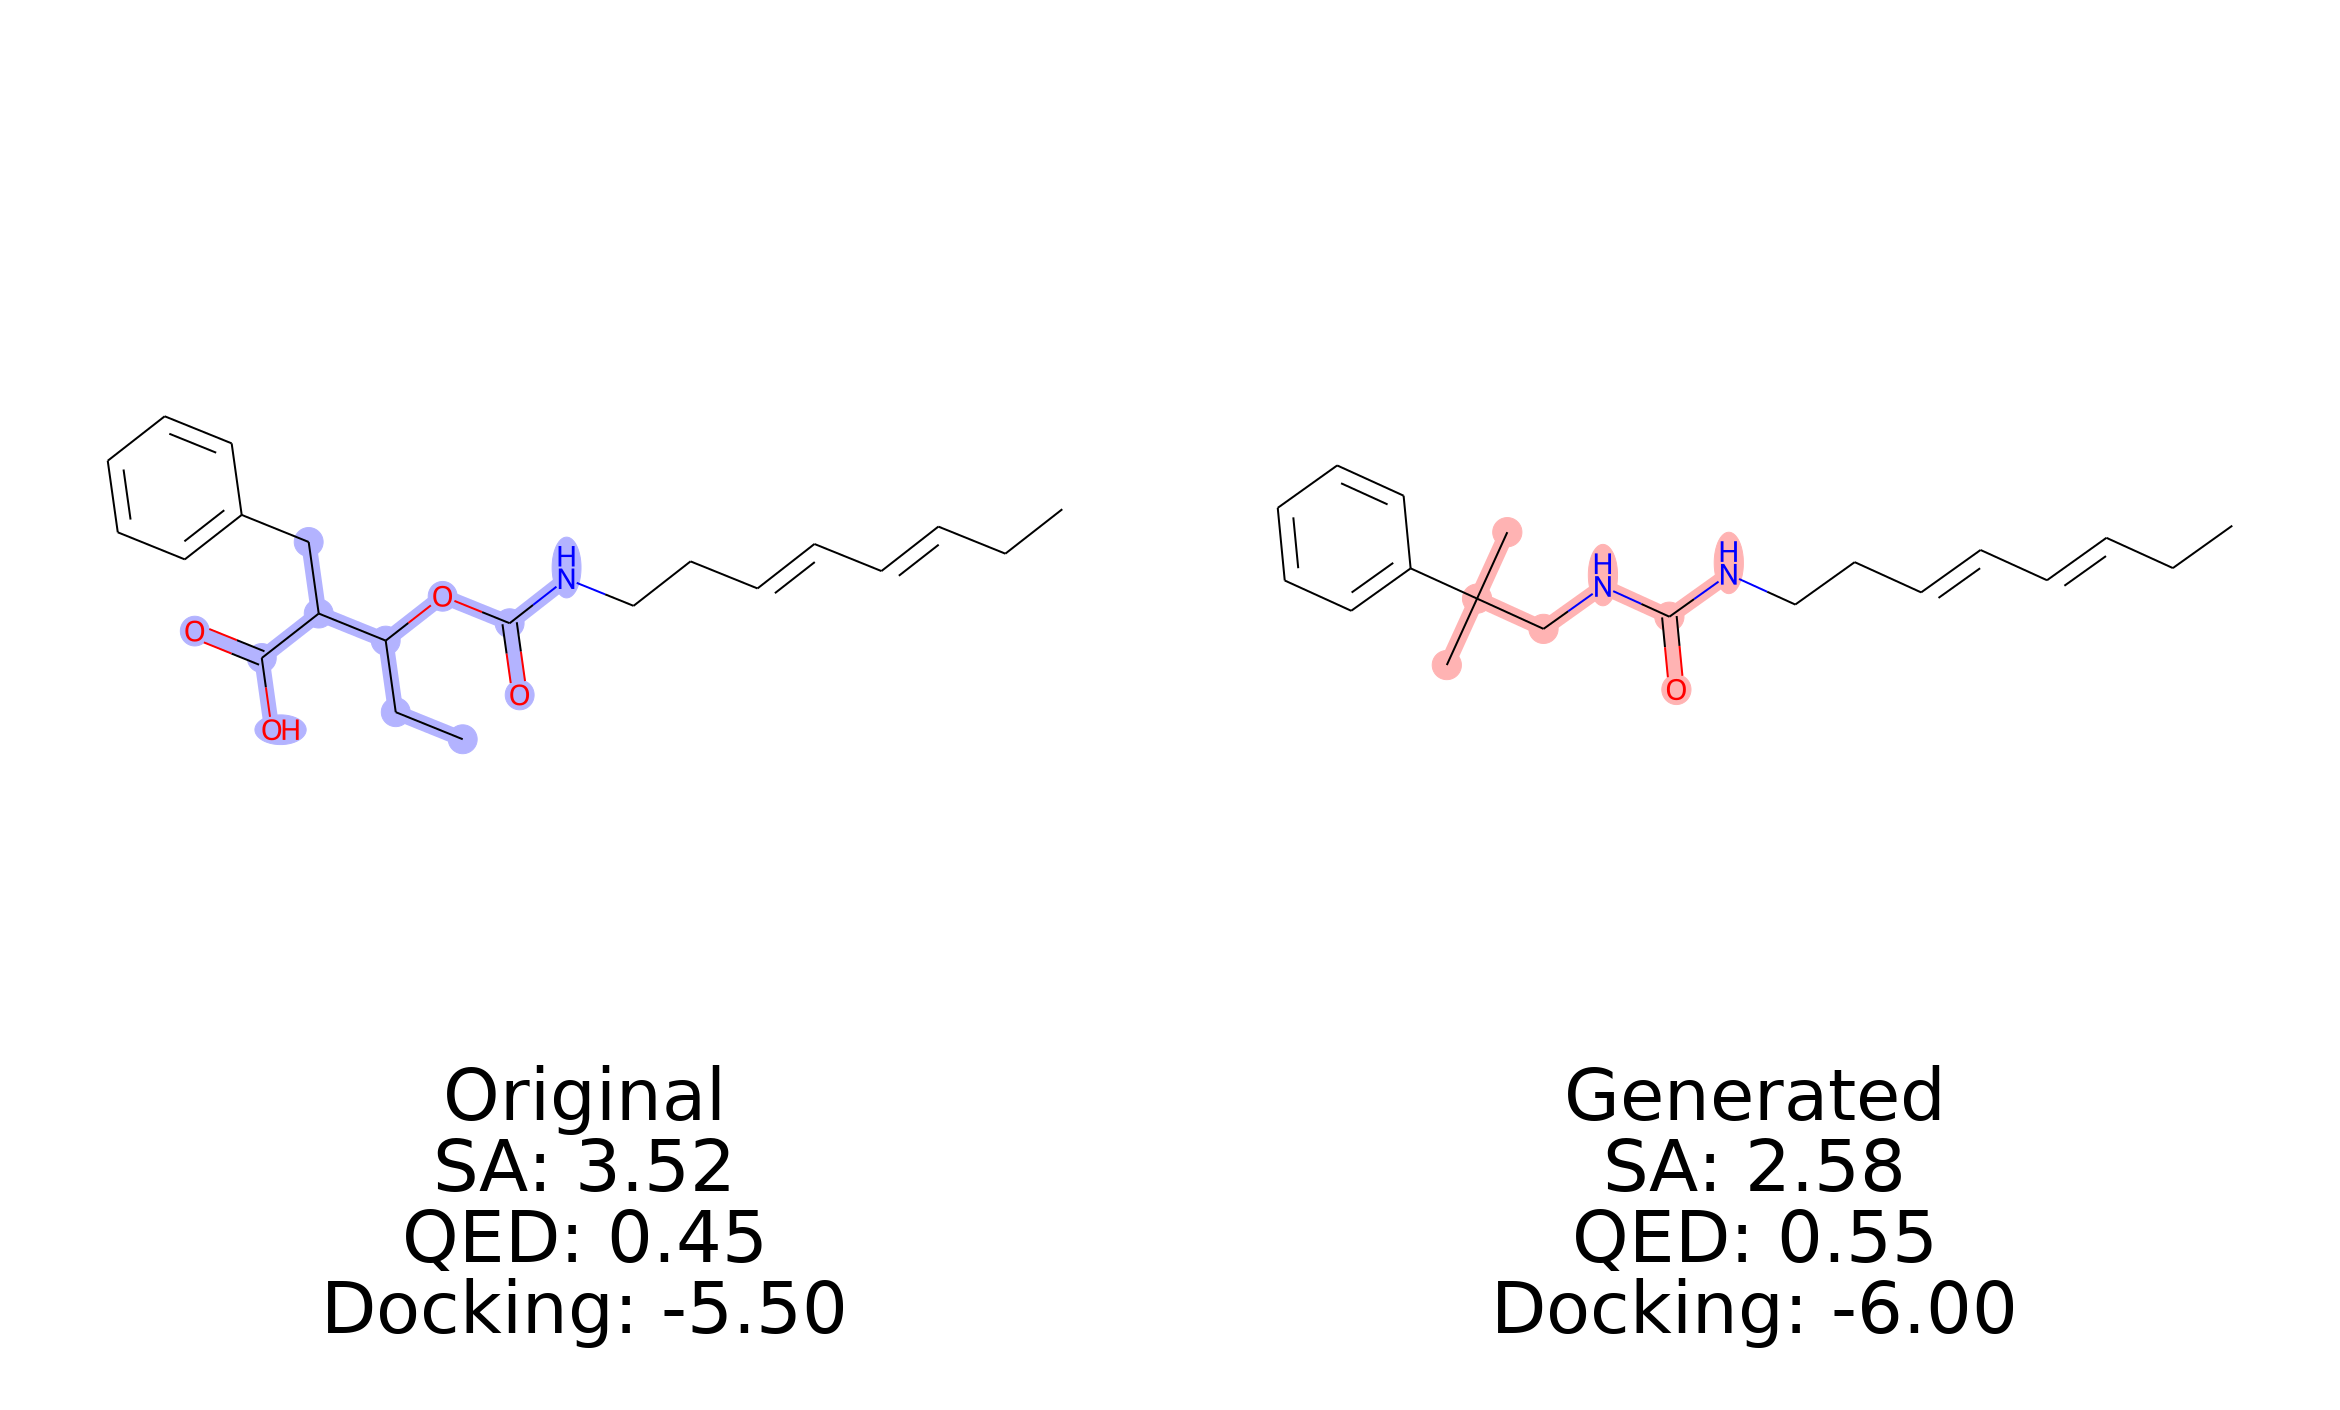

In [23]:
row = df.iloc[0]
print(row)
img = draw_mols(
    original_smi=row["INPUT-MOL-SMI"],
    generated_smi=row["GEN-MOL-SMI"],
    original_sa=row["SA"] - row["SA_DIFF"],
    original_qed=row["QED"] - row["QED_DIFF"],
    original_docking=row["INPUT-MOL-DOCKED-SCORE"],
    generated_sa=row["SA"],
    generated_qed=row["QED"],
    generated_docking=row["GEN-MOL-DOCKED-SCORE"],
    leaving_frag_smi=row["LEAVING-FRAG-SMI"],
    inserting_frag_smi=row["INSERTING-FRAG-SMI"],
    scale=3,
)
img

In [25]:
type(file)

str

In [27]:
file = Path(file)
for i in range(len(df)):
    row = df.iloc[i]
    img = draw_mols(
        original_smi=row["INPUT-MOL-SMI"],
        generated_smi=row["GEN-MOL-SMI"],
        original_sa=row["SA"] - row["SA_DIFF"],
        original_qed=row["QED"] - row["QED_DIFF"],
        original_docking=row["INPUT-MOL-DOCKED-SCORE"],
        generated_sa=row["SA"],
        generated_qed=row["QED"],
        generated_docking=row["GEN-MOL-DOCKED-SCORE"],
        leaving_frag_smi=row["LEAVING-FRAG-SMI"],
        inserting_frag_smi=row["INSERTING-FRAG-SMI"],
        scale=3,
    )
    img.save(f"20250826_new_data_main_model/figures/{file.stem}/{i}.png")

In [28]:
df.to_csv("20250826_new_data_main_model/filtered_results_68.csv", index=False)